# Evaluasi Eksperimen 1: Baseline Feature Extraction
Notebook ini mengevaluasi performa sistem rekomendasi menggunakan fitur
**baseline (ImageNet, tanpa fine-tuning)** yang telah diekstrak pada Eksperimen 1.

- **Fitur dimuat dari:** `features/exp1_baseline/`
- **Metrik:** Precision@K, Recall@K, F1@K, NDCG@K, Intra-List Diversity
- **Ground truth:** berbasis kategori pakaian (intra-category relevance)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Konfigurasi Path — ganti BASE_DIR jika menjalankan di environment berbeda
BASE_DIR   = '/mnt/d/Antigravity/Visual Based Rekomender Sistem'
# Untuk Windows native (tanpa WSL):
# BASE_DIR = r'd:\Antigravity\Visual Based Rekomender Sistem'

DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
FEAT_DIR    = os.path.join(BASE_DIR, 'features', 'exp1_baseline')
EVAL_DIR    = os.path.join(BASE_DIR, 'evaluation', 'exp1_baseline')
os.makedirs(EVAL_DIR, exist_ok=True)

# Suffix nama file fitur
FEAT_SUFFIX = '_features_baseline.npy'
IDX_SUFFIX  = '_valid_idx_baseline.npy'

MODEL_NAMES = ['resnet50', 'vgg19', 'inceptionv3', 'mobilenetv3']
K_VALUES    = [5, 10, 20]
N_USERS     = 100   # simulasi user
N_LIKED     = 3     # item awal yang "disukai" tiap user

print(f"FEAT_DIR : {FEAT_DIR}")
print(f"EVAL_DIR : {EVAL_DIR}")
print("✅ Config loaded.")


FEAT_DIR : /mnt/d/Antigravity/Visual Based Rekomender Sistem/features/exp1_baseline
EVAL_DIR : /mnt/d/Antigravity/Visual Based Rekomender Sistem/evaluation/exp1_baseline
✅ Config loaded.


In [3]:
# Load master dataset sebagai katalog item
MASTER_CSV = os.path.join(DATASET_DIR, 'master_dataset.csv')
df_master  = pd.read_csv(MASTER_CSV)

print(f"Total rows   : {len(df_master):,}")
print(f"Columns      : {df_master.columns.tolist()}")
print(f"Categories   : {df_master['category'].nunique()}")
print()
print(df_master.head(3))


Total rows   : 7,975
Columns      : ['image_name', 'full_path', 'gender', 'category', 'item_id', 'clothes_type', 'clothes_type_label', 'pose_type', 'pose_type_label', 'x1', 'y1', 'x2', 'y2', 'split', 'db_idx']
Categories   : 16

                                          image_name  \
0  img/WOMEN/Blouses_Shirts/id_00000001/02_1_fron...   
1       img/WOMEN/Dresses/id_00000002/02_1_front.jpg   
2        img/WOMEN/Skirts/id_00000003/02_1_front.jpg   

                                           full_path gender        category  \
0  /content/drive/MyDrive/fashion_recommender/In-...  WOMEN  Blouses_Shirts   
1  /content/drive/MyDrive/fashion_recommender/In-...  WOMEN         Dresses   
2  /content/drive/MyDrive/fashion_recommender/In-...  WOMEN          Skirts   

       item_id  clothes_type clothes_type_label  pose_type pose_type_label  \
0  id_00000001             1         upper-body          1           front   
1  id_00000002             3          full-body          1           fron

In [4]:
def precision_at_k(recommended_ids, relevant_ids, k):
    top_k = recommended_ids[:k]
    hits  = len(set(top_k) & set(relevant_ids))
    return hits / k

def recall_at_k(recommended_ids, relevant_ids, k):
    if len(relevant_ids) == 0:
        return 0.0
    top_k = recommended_ids[:k]
    hits  = len(set(top_k) & set(relevant_ids))
    return hits / len(relevant_ids)

def f1_at_k(recommended_ids, relevant_ids, k):
    p = precision_at_k(recommended_ids, relevant_ids, k)
    r = recall_at_k(recommended_ids, relevant_ids, k)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

def dcg_at_k(recommended_ids, relevant_ids, k):
    top_k = recommended_ids[:k]
    return sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k) if item in relevant_ids)

def ndcg_at_k(recommended_ids, relevant_ids, k):
    actual_dcg = dcg_at_k(recommended_ids, relevant_ids, k)
    ideal_dcg  = dcg_at_k(list(relevant_ids)[:k], relevant_ids, k)
    return actual_dcg / ideal_dcg if ideal_dcg > 0 else 0.0

def intra_list_diversity(recommended_ids, feature_matrix, item_id_to_idx):
    indices = [item_id_to_idx[i] for i in recommended_ids if i in item_id_to_idx]
    if len(indices) < 2:
        return 0.0
    vecs       = feature_matrix[indices]
    sim_matrix = vecs @ vecs.T
    n          = len(indices)
    pairs      = [(i, j) for i in range(n) for j in range(i + 1, n)]
    diversity  = sum(1 - sim_matrix[i, j] for i, j in pairs)
    return diversity / len(pairs)

print("✅ Fungsi metrik siap.")


✅ Fungsi metrik siap.


In [5]:
def build_user_profile(liked_indices, feature_matrix):
    vecs    = feature_matrix[liked_indices]
    profile = np.mean(vecs, axis=0)
    norm    = np.linalg.norm(profile)
    return profile / norm if norm > 0 else profile

def get_recommendations(user_profile, feature_matrix, exclude_indices, top_n=20):
    scores                  = feature_matrix @ user_profile
    scores[exclude_indices] = -1.0
    ranked_idx              = np.argsort(scores)[::-1]
    ranked_idx              = [i for i in ranked_idx if i not in set(exclude_indices)]
    return [(i, float(scores[i])) for i in ranked_idx[:top_n]]

print("✅ Helper fungsi rekomendasi siap.")


✅ Helper fungsi rekomendasi siap.


In [6]:
def simulate_evaluation(feature_matrix, df_sub, n_users=100, n_liked=3, k_values=[5, 10, 20]):
    item_id_to_idx = {row['item_id']: idx for idx, row in df_sub.iterrows()}
    categories     = df_sub['category'].unique()

    results = {k: {'precision': [], 'recall': [], 'f1': [], 'ndcg': [], 'diversity': []}
               for k in k_values}
    rng = np.random.default_rng(42)

    for _ in tqdm(range(n_users), desc="Simulating users"):
        cat       = rng.choice(categories)
        cat_items = df_sub[df_sub['category'] == cat]['item_id'].tolist()
        if len(cat_items) < n_liked + 5:
            continue

        liked_ids    = rng.choice(cat_items, size=n_liked, replace=False).tolist()
        liked_idx    = [item_id_to_idx[i] for i in liked_ids]
        relevant_ids = [i for i in cat_items if i not in set(liked_ids)]

        user_profile = build_user_profile(liked_idx, feature_matrix)
        recs         = get_recommendations(user_profile, feature_matrix,
                                           exclude_indices=liked_idx, top_n=max(k_values))
        rec_ids      = [df_sub.iloc[idx]['item_id'] for idx, _ in recs]

        for k in k_values:
            results[k]['precision'].append(precision_at_k(rec_ids, relevant_ids, k))
            results[k]['recall'].append(recall_at_k(rec_ids, relevant_ids, k))
            results[k]['f1'].append(f1_at_k(rec_ids, relevant_ids, k))
            results[k]['ndcg'].append(ndcg_at_k(rec_ids, relevant_ids, k))
            results[k]['diversity'].append(intra_list_diversity(rec_ids[:k], feature_matrix, item_id_to_idx))

    return {k: {m: np.mean(v) for m, v in results[k].items()} for k in k_values}

print("✅ Fungsi simulasi siap.")


✅ Fungsi simulasi siap.


In [7]:
all_results = {}

for model_name in MODEL_NAMES:
    feat_path = os.path.join(FEAT_DIR, f'{model_name}{FEAT_SUFFIX}')
    idx_path  = os.path.join(FEAT_DIR, f'{model_name}{IDX_SUFFIX}')

    if not os.path.exists(feat_path):
        print(f"⚠️  File tidak ditemukan: {feat_path} — skip.")
        continue

    print(f"\n{'='*55}")
    print(f"  📊 Evaluating: {model_name.upper()}")
    print(f"{'='*55}")

    feat_mat  = np.load(feat_path)
    valid_idx = np.load(idx_path).tolist()
    print(f"  Feature shape : {feat_mat.shape}")
    print(f"  Valid items   : {len(valid_idx)}")

    # Subset master_dataset sesuai valid_idx
    df_sub = df_master.iloc[valid_idx].reset_index(drop=True).copy()
    df_sub['item_id'] = range(len(df_sub))

    summary = simulate_evaluation(
        feature_matrix=feat_mat,
        df_sub=df_sub,
        n_users=N_USERS,
        n_liked=N_LIKED,
        k_values=K_VALUES,
    )
    all_results[model_name] = summary

    for k, metrics in summary.items():
        print(f"  K={k:2d}: P={metrics['precision']:.4f} | R={metrics['recall']:.4f} | "
              f"F1={metrics['f1']:.4f} | NDCG={metrics['ndcg']:.4f} | Div={metrics['diversity']:.4f}")

    del feat_mat
    import gc; gc.collect()

print("\n🎉 Evaluasi selesai!")



  📊 Evaluating: RESNET50
  Feature shape : (7975, 2048)
  Valid items   : 7975


Simulating users:   0%|          | 0/100 [00:00<?, ?it/s]

  K= 5: P=0.3900 | R=0.0120 | F1=0.0225 | NDCG=0.4079 | Div=0.1129
  K=10: P=0.3700 | R=0.0209 | F1=0.0370 | NDCG=0.3872 | Div=0.1177
  K=20: P=0.3320 | R=0.0357 | F1=0.0572 | NDCG=0.3542 | Div=0.1247

  📊 Evaluating: VGG19
  Feature shape : (7975, 512)
  Valid items   : 7975


Simulating users:   0%|          | 0/100 [00:00<?, ?it/s]

  K= 5: P=0.3320 | R=0.0096 | F1=0.0179 | NDCG=0.3479 | Div=0.1059
  K=10: P=0.3300 | R=0.0187 | F1=0.0329 | NDCG=0.3409 | Div=0.1117
  K=20: P=0.3030 | R=0.0344 | F1=0.0548 | NDCG=0.3181 | Div=0.1194

  📊 Evaluating: INCEPTIONV3
  Feature shape : (7975, 2048)
  Valid items   : 7975


Simulating users:   0%|          | 0/100 [00:00<?, ?it/s]

  K= 5: P=0.3960 | R=0.0109 | F1=0.0204 | NDCG=0.3994 | Div=0.1463
  K=10: P=0.3660 | R=0.0200 | F1=0.0354 | NDCG=0.3772 | Div=0.1507
  K=20: P=0.3345 | R=0.0341 | F1=0.0552 | NDCG=0.3509 | Div=0.1577

  📊 Evaluating: MOBILENETV3
  Feature shape : (7975, 960)
  Valid items   : 7975


Simulating users:   0%|          | 0/100 [00:00<?, ?it/s]

  K= 5: P=0.3900 | R=0.0114 | F1=0.0212 | NDCG=0.3878 | Div=0.1483
  K=10: P=0.3530 | R=0.0205 | F1=0.0360 | NDCG=0.3638 | Div=0.1571
  K=20: P=0.3230 | R=0.0357 | F1=0.0567 | NDCG=0.3392 | Div=0.1693

🎉 Evaluasi selesai!


In [8]:
rows = []
for model_name, result in all_results.items():
    for k, metrics in result.items():
        rows.append({
            'Model'    : model_name,
            'K'        : k,
            'Precision': round(metrics['precision'],  4),
            'Recall'   : round(metrics['recall'],     4),
            'F1'       : round(metrics['f1'],         4),
            'NDCG'     : round(metrics['ndcg'],       4),
            'Diversity': round(metrics['diversity'],  4),
        })

df_eval = pd.DataFrame(rows)
print("\n📊 TABEL EVALUASI — EKSPERIMEN 1 BASELINE:\n")
print(df_eval.to_string(index=False))

eval_csv = os.path.join(EVAL_DIR, 'evaluation_exp1_baseline.csv')
df_eval.to_csv(eval_csv, index=False)
print(f"\n💾 Tersimpan: {eval_csv}")



📊 TABEL EVALUASI — EKSPERIMEN 1 BASELINE:

      Model  K  Precision  Recall     F1   NDCG  Diversity
   resnet50  5     0.3900  0.0120 0.0225 0.4079     0.1129
   resnet50 10     0.3700  0.0209 0.0370 0.3872     0.1177
   resnet50 20     0.3320  0.0357 0.0572 0.3542     0.1247
      vgg19  5     0.3320  0.0096 0.0179 0.3479     0.1059
      vgg19 10     0.3300  0.0187 0.0329 0.3409     0.1117
      vgg19 20     0.3030  0.0344 0.0548 0.3181     0.1194
inceptionv3  5     0.3960  0.0109 0.0204 0.3994     0.1463
inceptionv3 10     0.3660  0.0200 0.0354 0.3772     0.1507
inceptionv3 20     0.3345  0.0341 0.0552 0.3509     0.1577
mobilenetv3  5     0.3900  0.0114 0.0212 0.3878     0.1483
mobilenetv3 10     0.3530  0.0205 0.0360 0.3638     0.1571
mobilenetv3 20     0.3230  0.0357 0.0567 0.3392     0.1693

💾 Tersimpan: /mnt/d/Antigravity/Visual Based Rekomender Sistem/evaluation/exp1_baseline/evaluation_exp1_baseline.csv


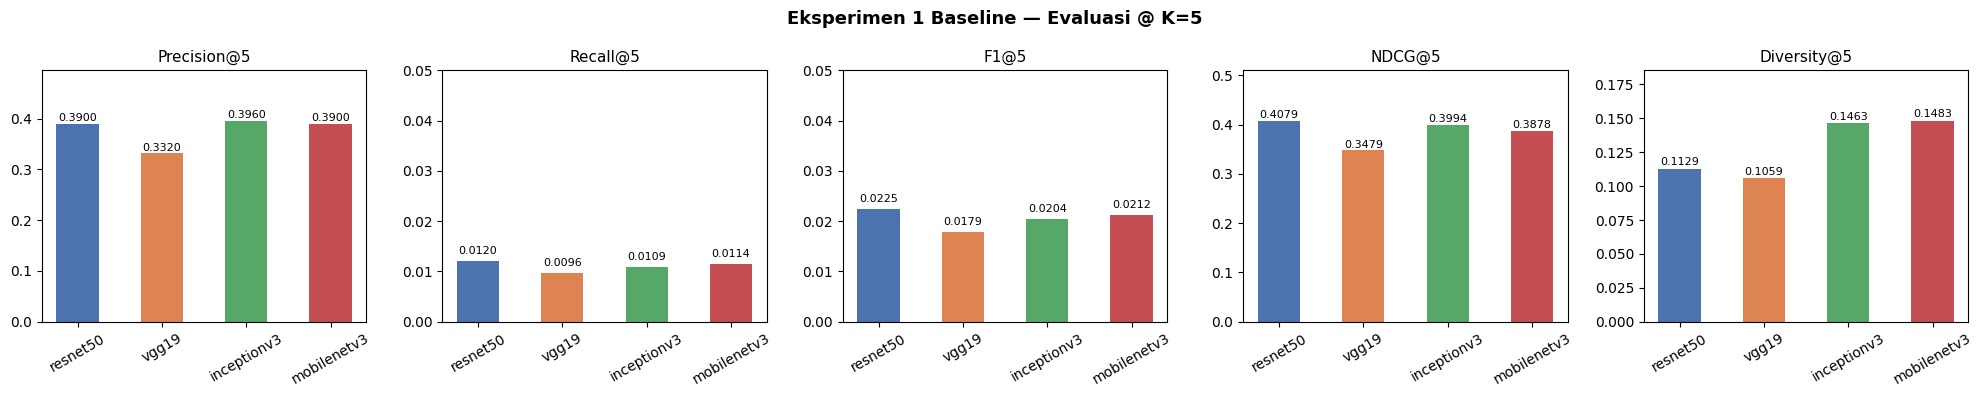

💾 Tersimpan: /mnt/d/Antigravity/Visual Based Rekomender Sistem/evaluation/exp1_baseline/eval_baseline_k5.png


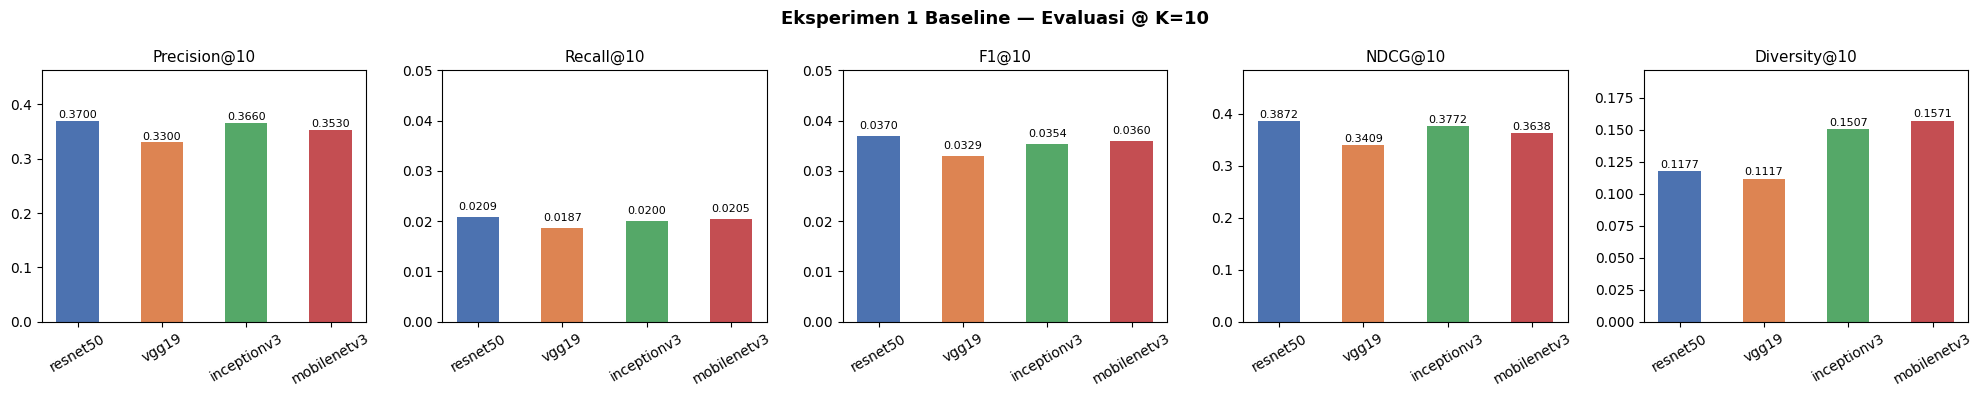

💾 Tersimpan: /mnt/d/Antigravity/Visual Based Rekomender Sistem/evaluation/exp1_baseline/eval_baseline_k10.png


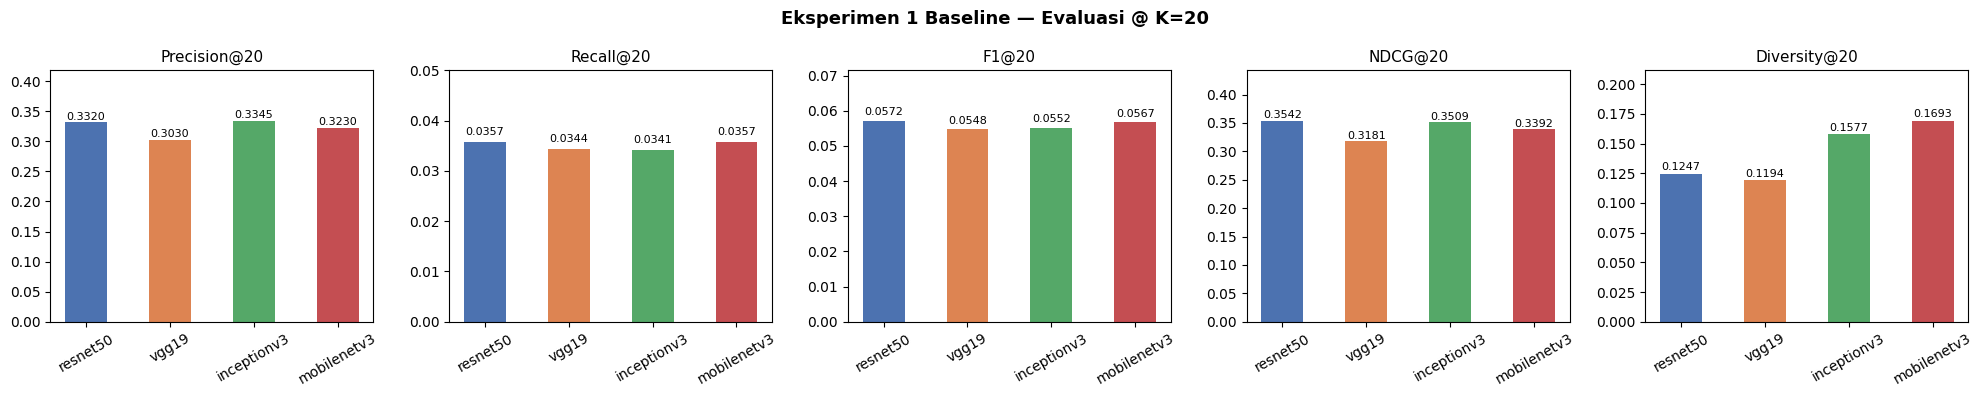

💾 Tersimpan: /mnt/d/Antigravity/Visual Based Rekomender Sistem/evaluation/exp1_baseline/eval_baseline_k20.png


In [9]:
metrics_to_plot = ['Precision', 'Recall', 'F1', 'NDCG', 'Diversity']
colors          = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for k in K_VALUES:
    df_k = df_eval[df_eval['K'] == k]
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 4))
    fig.suptitle(f'Eksperimen 1 Baseline — Evaluasi @ K={k}', fontsize=13, fontweight='bold')

    for ax, metric in zip(axes, metrics_to_plot):
        bars = ax.bar(df_k['Model'], df_k[metric], color=colors[:len(df_k)], width=0.5)
        ax.set_title(f'{metric}@{k}', fontsize=11)
        ax.set_ylim(0, max(df_k[metric].max() * 1.25, 0.05))
        ax.tick_params(axis='x', rotation=30)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2.,
                    bar.get_height() + 0.001,
                    f'{bar.get_height():.4f}',
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    out_png = os.path.join(EVAL_DIR, f'eval_baseline_k{k}.png')
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Tersimpan: {out_png}")


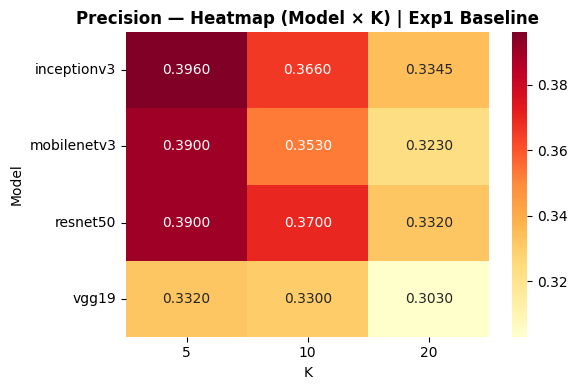

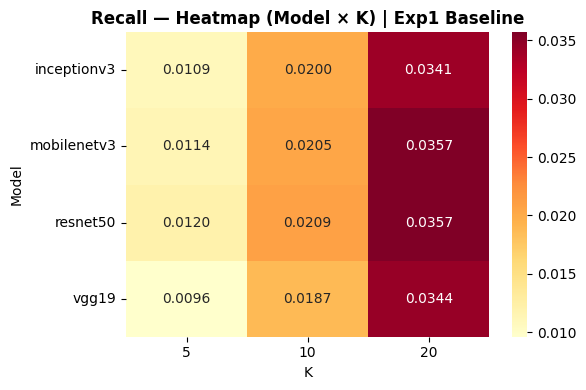

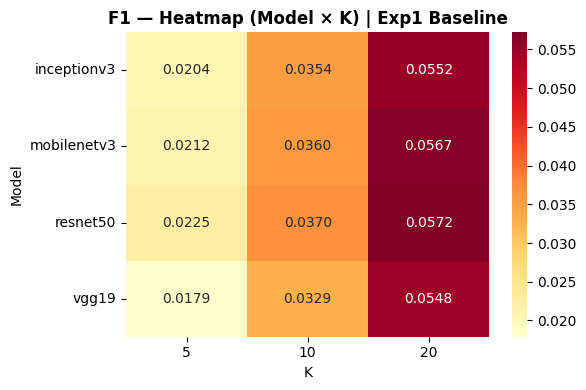

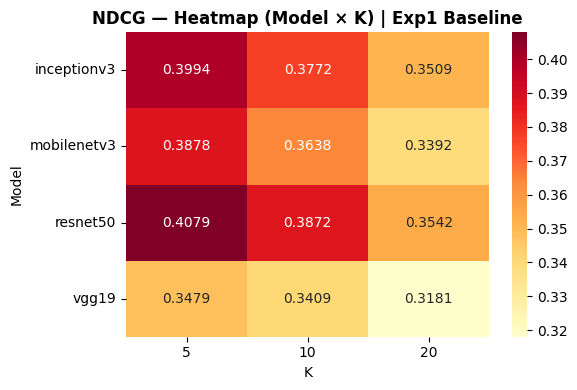

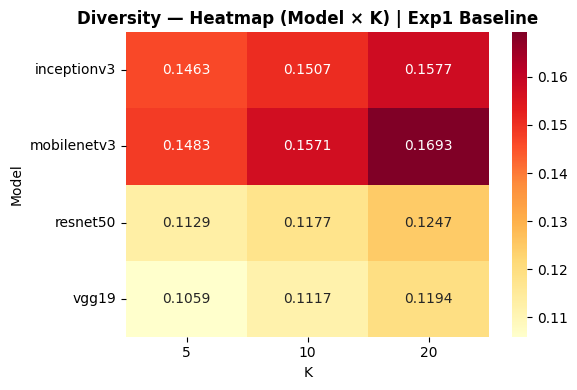

In [10]:
for metric in metrics_to_plot:
    pivot = df_eval.pivot(index='Model', columns='K', values=metric)
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'{metric} — Heatmap (Model × K) | Exp1 Baseline', fontweight='bold')
    plt.tight_layout()
    out_png = os.path.join(EVAL_DIR, f'heatmap_{metric.lower()}_baseline.png')
    plt.savefig(out_png, dpi=150)
    plt.show()


In [11]:
print("\n" + "="*55)
print("  📌 KESIMPULAN EVALUASI — EKSPERIMEN 1 BASELINE")
print("="*55)
k10 = df_eval[df_eval['K'] == 10]
for metric in ['F1', 'NDCG', 'Diversity']:
    best_row = k10.loc[k10[metric].idxmax()]
    print(f"  Best {metric}@10 : {best_row['Model'].upper()} ({best_row[metric]:.4f})")
print("="*55)



  📌 KESIMPULAN EVALUASI — EKSPERIMEN 1 BASELINE
  Best F1@10 : RESNET50 (0.0370)
  Best NDCG@10 : RESNET50 (0.3872)
  Best Diversity@10 : MOBILENETV3 (0.1571)
